# 1. IMPORT LIBRARIES + DATASET

In [9]:
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
transaction = pd.read_csv("Data_Transaction.csv")

# 2. FIRST GLANCE

In [11]:
# 5 dòng đầu
transaction.head()

,TRANS_LV1,TRANS_LV2,TRANS_DATE,DAY_OF_WEEK,TRANS_HOUR,TRANS_NO,TRANS_AMOUNT,CUSTOMER_NUMBER
0,Transfer,Outside_bank,2019-01-03,Thu,17,2,189771864.0,701619
1,Transfer,Outside_bank,2019-07-01,Mon,13,2,30224900.0,701619
2,Transfer,Outside_bank,2019-01-02,Wed,15,1,100000.0,701619
3,Payment,Credit_card_repayment,2019-01-03,Thu,14,1,85000000.0,262123
4,Payment,Credit_card_repayment,2019-01-28,Mon,22,1,83000000.0,262123


In [12]:
# 10 dòng ngẫu nhiên
transaction.sample(10)

,TRANS_LV1,TRANS_LV2,TRANS_DATE,DAY_OF_WEEK,TRANS_HOUR,TRANS_NO,TRANS_AMOUNT,CUSTOMER_NUMBER
755429,Transfer,Outside_bank,2019-10-22,Tue,9,1,500000.0,415525
1041717,Transfer,Outside_bank,2019-10-25,Fri,22,1,15000000.0,588694
1318923,Transfer,Outside_bank,2019-07-08,Mon,17,1,2300000.0,802449
100023,Transfer,Outside_bank,2019-12-26,Thu,19,1,200000.0,728107
40207,Transfer,Outside_bank,2019-12-03,Tue,20,1,1491200.0,658218
263787,Transfer,Outside_bank,2019-09-24,Tue,18,1,1000000.0,732082
694848,Transfer,Outside_bank,2019-08-05,Mon,18,1,500000.0,635218
893131,Transfer,Within_bank,2019-11-26,Tue,15,2,9200000.0,159107
553602,Topup,Mobile,2019-12-19,Thu,6,1,20000.0,456923
118180,Topup,Mobile,2019-07-17,Wed,16,1,200000.0,296038


In [13]:
# Mô tả dữ liệu
print("--- DESCRIPTION ---")
transaction.describe(include = "all")

--- DESCRIPTION ---


,TRANS_LV1,TRANS_LV2,TRANS_DATE,DAY_OF_WEEK,TRANS_HOUR,TRANS_NO,TRANS_AMOUNT,CUSTOMER_NUMBER
count,1418030,1418030,1418030,1418030,1.418030e+06,1.418030e+06,1.418030e+06,1.418030e+06
unique,3,14,364,7,NaN,NaN,NaN,NaN
top,Transfer,Outside_bank,2019-12-31,Mon,NaN,NaN,NaN,NaN
freq,989851,759815,13594,226862,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,1.394992e+01,1.185300e+00,8.770490e+06,4.993032e+05
std,NaN,NaN,NaN,NaN,4.874900e+00,1.114123e+00,4.010585e+07,2.887231e+05
min,NaN,NaN,NaN,NaN,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,NaN,NaN,NaN,NaN,1.000000e+01,1.000000e+00,1.100000e+05,2.460650e+05
50%,NaN,NaN,NaN,NaN,1.400000e+01,1.000000e+00,6.400000e+05,4.988880e+05
75%,NaN,NaN,NaN,NaN,1.800000e+01,1.000000e+00,3.000000e+06,7.511770e+05


In [14]:
# Thông tin cơ bản
print("--- INFORMATION ---")
transaction.info()

--- INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1418030 entries, 0 to 1418029
Data columns (total 8 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   TRANS_LV1        1418030 non-null  object 
 1   TRANS_LV2        1418030 non-null  object 
 2   TRANS_DATE       1418030 non-null  object 
 3   DAY_OF_WEEK      1418030 non-null  object 
 4   TRANS_HOUR       1418030 non-null  int64  
 5   TRANS_NO         1418030 non-null  int64  
 6   TRANS_AMOUNT     1418030 non-null  float64
 7   CUSTOMER_NUMBER  1418030 non-null  int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 86.5+ MB


In [15]:
# Kích thước tập dữ liệu
print("--- SHAPE ---")
print(f"Số dòng: {transaction.shape[0]} dòng")
print(f"Số cột: {transaction.shape[1]} cột")

--- SHAPE ---
Số dòng: 1418030 dòng
Số cột: 8 cột


In [16]:
# Kiểm tra dữ liệu thiếu
print("--- CHECK MISSING VALUE ---")
transaction.isna().sum()

--- CHECK MISSING VALUE ---


TRANS_LV1          0
TRANS_LV2          0
TRANS_DATE         0
DAY_OF_WEEK        0
TRANS_HOUR         0
TRANS_NO           0
TRANS_AMOUNT       0
CUSTOMER_NUMBER    0
dtype: int64

# 3. DATA CLEANING

## 3.1. Chuẩn hoá kiểu dữ liệu + kiểm tra chất lượng

Dữ liệu này khác lending/deposit: mỗi dòng là một **giao dịch chi tiết theo ngày/giờ**, không phải snapshot theo tháng. `TRANS_NO` là số lượng giao dịch gộp trong dòng đó (cùng khách, cùng ngày, cùng giờ, cùng loại giao dịch), `TRANS_AMOUNT` là tổng giá trị của các giao dịch đó.

Trước khi tổng hợp lên cấp tháng, cần: chuyển `TRANS_DATE` sang datetime, kiểm tra trùng lặp, và loại các `CUSTOMER_NUMBER` bất thường (giống lỗi dữ liệu đã gặp ở bảng deposit).

In [17]:
transaction["TRANS_DATE"] = pd.to_datetime(transaction["TRANS_DATE"], errors = "coerce")

# Kiểm tra trùng lặp ở cấp giao dịch (customer + ngày + giờ + loại giao dịch)
n_dup = transaction.duplicated(subset=["CUSTOMER_NUMBER","TRANS_DATE","TRANS_HOUR","TRANS_LV1","TRANS_LV2"]).sum()
print(f"Số dòng trùng lặp (cùng khách/ngày/giờ/loại GD): {n_dup}")

# Kiểm tra CUSTOMER_NUMBER bất thường (giống lỗi đã gặp ở bảng deposit)
n_invalid_cust = (transaction["CUSTOMER_NUMBER"] == 0).sum()
print(f"Số dòng có CUSTOMER_NUMBER = 0: {n_invalid_cust}")
transaction = transaction[transaction["CUSTOMER_NUMBER"] != 0].copy()

# Kiểm tra TRANS_AMOUNT / TRANS_NO không hợp lệ (<= 0)
print(f"Số dòng TRANS_AMOUNT <= 0: {(transaction['TRANS_AMOUNT'] <= 0).sum()}")
print(f"Số dòng TRANS_NO <= 0: {(transaction['TRANS_NO'] <= 0).sum()}")

print(f"Số dòng còn lại: {len(transaction)}")

Số dòng trùng lặp (cùng khách/ngày/giờ/loại GD): 0
Số dòng có CUSTOMER_NUMBER = 0: 10
Số dòng TRANS_AMOUNT <= 0: 0
Số dòng TRANS_NO <= 0: 0
Số dòng còn lại: 1418020


## 3.2. Tổng hợp giao dịch lên cấp CUSTOMER x MONTH

Vì lending_feature_table và deposit_feature_table đều ở cấp customer-tháng, mình tổng hợp transaction về cùng cấp độ đó để dễ merge ở bước sau. Các đặc trưng hành vi được tạo thêm ở bước này (không có trong 2 bảng kia) vì bản chất dữ liệu giao dịch cho phép:
- `TXN_COUNT`: tổng số giao dịch trong tháng
- `TOTAL_TRANS_AMOUNT`: tổng giá trị giao dịch trong tháng
- `AVG_TRANS_AMOUNT_PER_TXN`: giá trị trung bình mỗi giao dịch
- `N_DISTINCT_TRANS_TYPE`: số loại giao dịch (TRANS_LV2) khác nhau khách sử dụng trong tháng — đo mức độ đa dạng hành vi
- `WEEKEND_AMOUNT_RATIO`, `NIGHT_AMOUNT_RATIO`: tỷ trọng giá trị giao dịch vào cuối tuần / giờ đêm (23h–5h) — các đặc trưng hành vi thường dùng để phát hiện bất thường
- `OUTSIDE_BANK_AMOUNT_RATIO`: tỷ trọng giá trị chuyển khoản ra ngoài ngân hàng

In [18]:
transaction["MONTH"] = transaction["TRANS_DATE"].values.astype("datetime64[M]")

transaction["IS_WEEKEND"] = transaction["DAY_OF_WEEK"].isin(["Sat", "Sun"]).astype(int)
transaction["IS_NIGHT"] = transaction["TRANS_HOUR"].isin([23, 0, 1, 2, 3, 4, 5]).astype(int)
transaction["IS_OUTSIDE_BANK"] = (transaction["TRANS_LV2"] == "Outside_bank").astype(int)

transaction["WEEKEND_AMOUNT"] = transaction["TRANS_AMOUNT"] * transaction["IS_WEEKEND"]
transaction["NIGHT_AMOUNT"] = transaction["TRANS_AMOUNT"] * transaction["IS_NIGHT"]
transaction["OUTSIDE_BANK_AMOUNT"] = transaction["TRANS_AMOUNT"] * transaction["IS_OUTSIDE_BANK"]

monthly_txn = transaction.groupby(["CUSTOMER_NUMBER", "MONTH"]).agg(
    TXN_COUNT = ("TRANS_NO", "sum"),
    TOTAL_TRANS_AMOUNT = ("TRANS_AMOUNT", "sum"),
    N_DISTINCT_TRANS_TYPE = ("TRANS_LV2", "nunique"),
    WEEKEND_AMOUNT = ("WEEKEND_AMOUNT", "sum"),
    NIGHT_AMOUNT = ("NIGHT_AMOUNT", "sum"),
    OUTSIDE_BANK_AMOUNT = ("OUTSIDE_BANK_AMOUNT", "sum")
).reset_index()

monthly_txn["AVG_TRANS_AMOUNT_PER_TXN"] = monthly_txn["TOTAL_TRANS_AMOUNT"] / monthly_txn["TXN_COUNT"]
monthly_txn["WEEKEND_AMOUNT_RATIO"] = monthly_txn["WEEKEND_AMOUNT"] / monthly_txn["TOTAL_TRANS_AMOUNT"]
monthly_txn["NIGHT_AMOUNT_RATIO"] = monthly_txn["NIGHT_AMOUNT"] / monthly_txn["TOTAL_TRANS_AMOUNT"]
monthly_txn["OUTSIDE_BANK_AMOUNT_RATIO"] = monthly_txn["OUTSIDE_BANK_AMOUNT"] / monthly_txn["TOTAL_TRANS_AMOUNT"]

monthly_txn.drop(columns=["WEEKEND_AMOUNT", "NIGHT_AMOUNT", "OUTSIDE_BANK_AMOUNT"], inplace=True)
monthly_txn.sort_values(["CUSTOMER_NUMBER", "MONTH"], inplace=True)
monthly_txn.head()

,CUSTOMER_NUMBER,MONTH,TXN_COUNT,TOTAL_TRANS_AMOUNT,N_DISTINCT_TRANS_TYPE,AVG_TRANS_AMOUNT_PER_TXN,WEEKEND_AMOUNT_RATIO,NIGHT_AMOUNT_RATIO,OUTSIDE_BANK_AMOUNT_RATIO
0,9,2019-12-01,6,11694976.0,3,1.949163e+06,0.055579,0.000000,0.855068
1,15,2019-10-01,1,23200000.0,1,2.320000e+07,0.000000,0.000000,1.000000
2,15,2019-12-01,2,28200000.0,1,1.410000e+07,0.177305,0.000000,1.000000
3,32,2019-09-01,3,1880000.0,1,6.266667e+05,0.000000,0.000000,1.000000
4,32,2019-10-01,4,660000.0,1,1.650000e+05,0.000000,0.151515,1.000000


## 3.3. Cắt ngưỡng Observation Window

Dùng cùng mốc `cutoff_date = 2019-10-01` như bảng lending và deposit để đồng bộ observation window (Jan–Sep 2019) giữa các bảng, tránh leak thông tin từ performance window (Oct–Dec 2019) khi merge chung vào master table sau này.

In [19]:
cutoff_date = pd.Timestamp("2019-10-01")
transaction_obs = monthly_txn[monthly_txn["MONTH"] < cutoff_date].copy()
print(f"Số dòng customer-tháng trong observation window: {len(transaction_obs)}")

Số dòng customer-tháng trong observation window: 91729


## 3.4. Xử lý outlier TOTAL_TRANS_AMOUNT / AVG_TRANS_AMOUNT_PER_TXN

Giống 2 bảng trước, giá trị giao dịch lệch phải mạnh (TRANS_AMOUNT gốc từ 1 tới ~2.46 tỷ). Winsorize tại percentile 99.5%, tính trên chính observation window.

In [20]:
total_cap = transaction_obs["TOTAL_TRANS_AMOUNT"].quantile(0.995)
avg_cap = transaction_obs["AVG_TRANS_AMOUNT_PER_TXN"].quantile(0.995)

n_total_capped = (transaction_obs["TOTAL_TRANS_AMOUNT"] > total_cap).sum()
n_avg_capped = (transaction_obs["AVG_TRANS_AMOUNT_PER_TXN"] > avg_cap).sum()

transaction_obs["TOTAL_TRANS_AMOUNT_CAPPED"] = transaction_obs["TOTAL_TRANS_AMOUNT"].clip(upper=total_cap)
transaction_obs["AVG_TRANS_AMOUNT_PER_TXN_CAPPED"] = transaction_obs["AVG_TRANS_AMOUNT_PER_TXN"].clip(upper=avg_cap)

print(f"Ngưỡng cap TOTAL_TRANS_AMOUNT (99.5%): {total_cap:,.0f} | số dòng bị cap: {n_total_capped}")
print(f"Ngưỡng cap AVG_TRANS_AMOUNT_PER_TXN (99.5%): {avg_cap:,.0f} | số dòng bị cap: {n_avg_capped}")

Ngưỡng cap TOTAL_TRANS_AMOUNT (99.5%): 1,726,286,542 | số dòng bị cap: 459
Ngưỡng cap AVG_TRANS_AMOUNT_PER_TXN (99.5%): 200,000,000 | số dòng bị cap: 414


Minh hoạ phân phối trước/sau log-transform cho TOTAL_TRANS_AMOUNT.

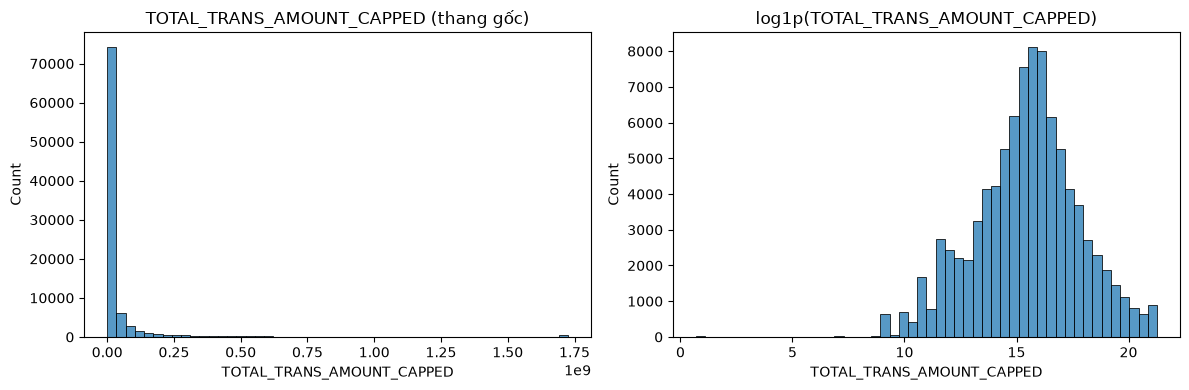

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(transaction_obs["TOTAL_TRANS_AMOUNT_CAPPED"], bins=50, ax=axes[0])
axes[0].set_title("TOTAL_TRANS_AMOUNT_CAPPED (thang gốc)")

sns.histplot(np.log1p(transaction_obs["TOTAL_TRANS_AMOUNT_CAPPED"]), bins=50, ax=axes[1])
axes[1].set_title("log1p(TOTAL_TRANS_AMOUNT_CAPPED)")

plt.tight_layout()
plt.show()

## 3.5. Đặc trưng SNAPSHOT (tháng gần nhất trong observation window)

In [22]:
idx_latest_txn = transaction_obs.groupby("CUSTOMER_NUMBER")["MONTH"].idxmax()
feat_txn_snapshot = transaction_obs.loc[idx_latest_txn, [
    "CUSTOMER_NUMBER", "TXN_COUNT", "TOTAL_TRANS_AMOUNT_CAPPED", "AVG_TRANS_AMOUNT_PER_TXN_CAPPED",
    "N_DISTINCT_TRANS_TYPE", "WEEKEND_AMOUNT_RATIO", "NIGHT_AMOUNT_RATIO", "OUTSIDE_BANK_AMOUNT_RATIO"
]].copy()

feat_txn_snapshot.rename(columns = {
    "TXN_COUNT": "LATEST_TXN_COUNT",
    "TOTAL_TRANS_AMOUNT_CAPPED": "LATEST_TOTAL_TRANS_AMOUNT",
    "AVG_TRANS_AMOUNT_PER_TXN_CAPPED": "LATEST_AVG_TRANS_AMOUNT_PER_TXN",
    "N_DISTINCT_TRANS_TYPE": "LATEST_N_DISTINCT_TRANS_TYPE",
    "WEEKEND_AMOUNT_RATIO": "LATEST_WEEKEND_AMOUNT_RATIO",
    "NIGHT_AMOUNT_RATIO": "LATEST_NIGHT_AMOUNT_RATIO",
    "OUTSIDE_BANK_AMOUNT_RATIO": "LATEST_OUTSIDE_BANK_AMOUNT_RATIO"
}, inplace = True)

# Log-transform song song với bản gốc (phân phối lệch phải mạnh)
feat_txn_snapshot["LOG_LATEST_TOTAL_TRANS_AMOUNT"] = np.log1p(feat_txn_snapshot["LATEST_TOTAL_TRANS_AMOUNT"])
feat_txn_snapshot["LOG_LATEST_AVG_TRANS_AMOUNT_PER_TXN"] = np.log1p(feat_txn_snapshot["LATEST_AVG_TRANS_AMOUNT_PER_TXN"])

# Cờ nhị phân — có ý nghĩa thật vì transaction_obs chỉ chứa các tháng khách THỰC SỰ phát sinh giao dịch
# (không giống HAS_ACTIVE_LOAN_OBS bên lending, vốn luôn = 1 do cấu trúc dữ liệu nguồn)
feat_txn_snapshot["HAS_ACTIVE_TXN_OBS"] = 1

feat_txn_snapshot.head()

,CUSTOMER_NUMBER,LATEST_TXN_COUNT,LATEST_TOTAL_TRANS_AMOUNT,LATEST_AVG_TRANS_AMOUNT_PER_TXN,LATEST_N_DISTINCT_TRANS_TYPE,LATEST_WEEKEND_AMOUNT_RATIO,LATEST_NIGHT_AMOUNT_RATIO,LATEST_OUTSIDE_BANK_AMOUNT_RATIO,LOG_LATEST_TOTAL_TRANS_AMOUNT,LOG_LATEST_AVG_TRANS_AMOUNT_PER_TXN,HAS_ACTIVE_TXN_OBS
3,32,3,1880000.0,6.266667e+05,1,0.000000,0.000000,1.000000,14.446783,13.348172,1
8,44,1,300000.0,3.000000e+05,1,0.000000,0.000000,1.000000,12.611541,12.611541,1
14,68,66,91635585.0,1.388418e+06,3,0.239895,0.001091,0.542264,18.333330,14.143676,1
18,88,176,408120129.0,2.318864e+06,2,0.144487,0.000000,0.282676,19.827072,14.656589,1
23,107,1,126000.0,1.260000e+05,1,1.000000,0.000000,1.000000,11.744045,11.744045,1


## 3.6. Đặc trưng HISTORY (lịch sử + quy mô trong observation window)

In [23]:
transaction_history = transaction_obs.groupby("CUSTOMER_NUMBER").agg(
    TXN_ACTIVE_MONTHS = ("MONTH", "nunique"),
    MAX_HIST_TOTAL_TRANS_AMOUNT = ("TOTAL_TRANS_AMOUNT_CAPPED", "max"),
    MEAN_HIST_TOTAL_TRANS_AMOUNT = ("TOTAL_TRANS_AMOUNT_CAPPED", "mean"),
    MEAN_HIST_TXN_COUNT = ("TXN_COUNT", "mean"),
    MAX_HIST_TXN_COUNT = ("TXN_COUNT", "max"),
    MEAN_HIST_N_DISTINCT_TRANS_TYPE = ("N_DISTINCT_TRANS_TYPE", "mean"),
    MEAN_HIST_WEEKEND_AMOUNT_RATIO = ("WEEKEND_AMOUNT_RATIO", "mean"),
    MEAN_HIST_NIGHT_AMOUNT_RATIO = ("NIGHT_AMOUNT_RATIO", "mean"),
    MEAN_HIST_OUTSIDE_BANK_AMOUNT_RATIO = ("OUTSIDE_BANK_AMOUNT_RATIO", "mean")
).reset_index()

# Log-transform song song với bản gốc
transaction_history["LOG_MAX_HIST_TOTAL_TRANS_AMOUNT"] = np.log1p(transaction_history["MAX_HIST_TOTAL_TRANS_AMOUNT"])
transaction_history["LOG_MEAN_HIST_TOTAL_TRANS_AMOUNT"] = np.log1p(transaction_history["MEAN_HIST_TOTAL_TRANS_AMOUNT"])

transaction_history.head()

,CUSTOMER_NUMBER,TXN_ACTIVE_MONTHS,MAX_HIST_TOTAL_TRANS_AMOUNT,MEAN_HIST_TOTAL_TRANS_AMOUNT,MEAN_HIST_TXN_COUNT,MAX_HIST_TXN_COUNT,MEAN_HIST_N_DISTINCT_TRANS_TYPE,MEAN_HIST_WEEKEND_AMOUNT_RATIO,MEAN_HIST_NIGHT_AMOUNT_RATIO,MEAN_HIST_OUTSIDE_BANK_AMOUNT_RATIO,LOG_MAX_HIST_TOTAL_TRANS_AMOUNT,LOG_MEAN_HIST_TOTAL_TRANS_AMOUNT
0,32,1,1880000.0,1880000.0,3.0,3,1.0,0.000000,0.000000,1.000000,14.446783,14.446783
1,44,2,800000.0,550000.0,1.0,1,1.0,0.000000,0.000000,1.000000,13.592368,13.217675
2,68,5,148217709.0,51134832.4,34.6,87,2.4,0.259737,0.010451,0.678649,18.814193,17.749976
3,88,1,408120129.0,408120129.0,176.0,176,2.0,0.144487,0.000000,0.282676,19.827072,19.827072
4,107,2,20100000.0,10113000.0,1.0,1,1.0,0.500000,0.000000,1.000000,16.816230,16.129332


## 3.7. Đặc trưng GROWTH (xu hướng thay đổi trong observation window)

Chuẩn hoá theo số tháng đã trôi qua giữa lần giao dịch đầu và cuối trong window (không dùng hiệu số tuyệt đối thuần), đồng thời thêm `RECENCY_MONTHS` — số tháng từ lần hoạt động gần nhất tới cutoff_date.

In [24]:
first_txn = transaction_obs.groupby("CUSTOMER_NUMBER").first().reset_index()
last_txn = transaction_obs.groupby("CUSTOMER_NUMBER").last().reset_index()

months_elapsed = (
    (last_txn["MONTH"].dt.year - first_txn["MONTH"].dt.year) * 12
    + (last_txn["MONTH"].dt.month - first_txn["MONTH"].dt.month)
)
months_elapsed_safe = months_elapsed.replace(0, np.nan)

amount_growth = last_txn["TOTAL_TRANS_AMOUNT_CAPPED"] - first_txn["TOTAL_TRANS_AMOUNT_CAPPED"]
count_growth = last_txn["TXN_COUNT"] - first_txn["TXN_COUNT"]

recency_months = (
    (cutoff_date.year - last_txn["MONTH"].dt.year) * 12
    + (cutoff_date.month - last_txn["MONTH"].dt.month)
)

growth_txn_df = pd.DataFrame({
    "CUSTOMER_NUMBER": first_txn["CUSTOMER_NUMBER"],
    "TOTAL_TRANS_AMOUNT_GROWTH": amount_growth,
    "TXN_COUNT_GROWTH": count_growth,
    "TOTAL_TRANS_AMOUNT_GROWTH_RATE": (amount_growth / months_elapsed_safe).fillna(0),
    "RECENCY_MONTHS": recency_months
})
transaction_history = transaction_history.merge(growth_txn_df, on = "CUSTOMER_NUMBER", how = "left")
transaction_history.head()

,CUSTOMER_NUMBER,TXN_ACTIVE_MONTHS,MAX_HIST_TOTAL_TRANS_AMOUNT,MEAN_HIST_TOTAL_TRANS_AMOUNT,MEAN_HIST_TXN_COUNT,MAX_HIST_TXN_COUNT,MEAN_HIST_N_DISTINCT_TRANS_TYPE,MEAN_HIST_WEEKEND_AMOUNT_RATIO,MEAN_HIST_NIGHT_AMOUNT_RATIO,MEAN_HIST_OUTSIDE_BANK_AMOUNT_RATIO,LOG_MAX_HIST_TOTAL_TRANS_AMOUNT,LOG_MEAN_HIST_TOTAL_TRANS_AMOUNT,TOTAL_TRANS_AMOUNT_GROWTH,TXN_COUNT_GROWTH,TOTAL_TRANS_AMOUNT_GROWTH_RATE,RECENCY_MONTHS
0,32,1,1880000.0,1880000.0,3.0,3,1.0,0.000000,0.000000,1.000000,14.446783,14.446783,0.0,0,0.0,1
1,44,2,800000.0,550000.0,1.0,1,1.0,0.000000,0.000000,1.000000,13.592368,13.217675,-500000.0,0,-500000.0,4
2,68,5,148217709.0,51134832.4,34.6,87,2.4,0.259737,0.010451,0.678649,18.814193,17.749976,89475585.0,64,14912597.5,1
3,88,1,408120129.0,408120129.0,176.0,176,2.0,0.144487,0.000000,0.282676,19.827072,19.827072,0.0,0,0.0,1
4,107,2,20100000.0,10113000.0,1.0,1,1.0,0.500000,0.000000,1.000000,16.816230,16.129332,-19974000.0,0,-19974000.0,1


## 3.8. Gộp + xử lý missing + lưu file

In [25]:
transaction_clean = feat_txn_snapshot.merge(transaction_history, on = "CUSTOMER_NUMBER", how = "outer").fillna(0)
transaction_clean.to_csv("transaction_clean.csv", index = False)

print(f"Xử lý xong Transaction Features! Kích thước: {transaction_clean.shape}")
transaction_clean.head()

Xử lý xong Transaction Features! Kích thước: (29882, 26)


,CUSTOMER_NUMBER,LATEST_TXN_COUNT,LATEST_TOTAL_TRANS_AMOUNT,LATEST_AVG_TRANS_AMOUNT_PER_TXN,LATEST_N_DISTINCT_TRANS_TYPE,LATEST_WEEKEND_AMOUNT_RATIO,LATEST_NIGHT_AMOUNT_RATIO,LATEST_OUTSIDE_BANK_AMOUNT_RATIO,LOG_LATEST_TOTAL_TRANS_AMOUNT,LOG_LATEST_AVG_TRANS_AMOUNT_PER_TXN,...,MEAN_HIST_N_DISTINCT_TRANS_TYPE,MEAN_HIST_WEEKEND_AMOUNT_RATIO,MEAN_HIST_NIGHT_AMOUNT_RATIO,MEAN_HIST_OUTSIDE_BANK_AMOUNT_RATIO,LOG_MAX_HIST_TOTAL_TRANS_AMOUNT,LOG_MEAN_HIST_TOTAL_TRANS_AMOUNT,TOTAL_TRANS_AMOUNT_GROWTH,TXN_COUNT_GROWTH,TOTAL_TRANS_AMOUNT_GROWTH_RATE,RECENCY_MONTHS
0,32,3,1880000.0,6.266667e+05,1,0.000000,0.000000,1.000000,14.446783,13.348172,...,1.0,0.000000,0.000000,1.000000,14.446783,14.446783,0.0,0,0.0,1
1,44,1,300000.0,3.000000e+05,1,0.000000,0.000000,1.000000,12.611541,12.611541,...,1.0,0.000000,0.000000,1.000000,13.592368,13.217675,-500000.0,0,-500000.0,4
2,68,66,91635585.0,1.388418e+06,3,0.239895,0.001091,0.542264,18.333330,14.143676,...,2.4,0.259737,0.010451,0.678649,18.814193,17.749976,89475585.0,64,14912597.5,1
3,88,176,408120129.0,2.318864e+06,2,0.144487,0.000000,0.282676,19.827072,14.656589,...,2.0,0.144487,0.000000,0.282676,19.827072,19.827072,0.0,0,0.0,1
4,107,1,126000.0,1.260000e+05,1,1.000000,0.000000,1.000000,11.744045,11.744045,...,1.0,0.500000,0.000000,1.000000,16.816230,16.129332,-19974000.0,0,-19974000.0,1
